In [3]:
from lagp.utils.generate_data import generate_input_grid, simulate_latentGP, simulate_response, obtain_quantile, train_test_split
from lagp.models.model import model_gpboost, model_gpytorch
from lagp.utils.metrics import quantile_score, interval_score, coverage_and_width
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import gpytorch as gpy
import numpy as np
import torch
import seaborn as sns
from scipy.stats import norm

# Set plot style to white
plt.style.use('ggplot')

In [4]:
# GENERATE DATA
N = 100
d = 2
lims = [0,100]
grid = generate_input_grid(d=d, sample_size=N, lims = lims)

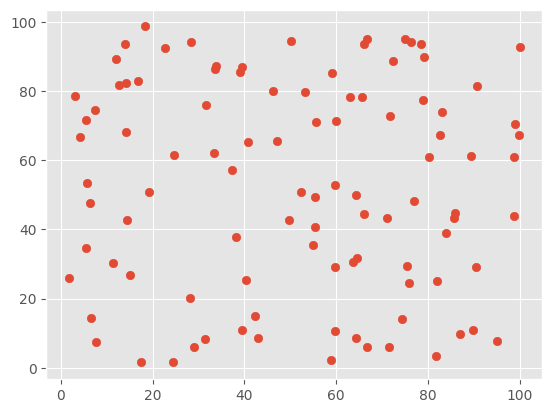

In [5]:
if d ==2:
    plt.scatter(grid[:,0], grid[:, 1])

In [6]:
nu = 1.5
lengthscale = 2.7
signal_variance = 2

base_kernel = gpy.kernels.MaternKernel(nu = nu)
# Set lengthscale
base_kernel.lengthscale = lengthscale
# Wrap with ScaleKernel to apply output scale (variance)
kernel = gpy.kernels.ScaleKernel(base_kernel)
kernel.outputscale = signal_variance

In [7]:
# check covariance
if d == 1:
    cov_matrix = kernel(torch.tensor(np.sort(grid.reshape(N))))
    # To get a numpy version of it, we need to convert the PyTorch tensor to numpy
    cov_matrix_np = cov_matrix.evaluate().detach().numpy()
    # Plot the covariance matrix as a heatmap
    plt.figure(figsize=(8, 6))  # Adjust figure size
    sns.heatmap(cov_matrix_np, cmap='viridis', annot=False, square=True)
    plt.title('Covariance Matrix Heatmap')
    plt.show()

In [8]:
try:
    cholesky_factor = np.linalg.cholesky(cov_matrix_np)
    print("Success Cholesky")
except:
    print("Failed Cholesky")

Failed Cholesky


In [9]:
f =  simulate_latentGP(X=grid, kernel=kernel, n_samples=1)# * np.sqrt(signal_variance)
print(f.shape)
f = f.reshape(N) # for plotting

(100, 1)


C:\Users\JumpStart\AppData\Local\Temp\ipykernel_4188\1022637129.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(grid[:, 0], grid[:,1], f, cmap='viridis', edgecolor='none')


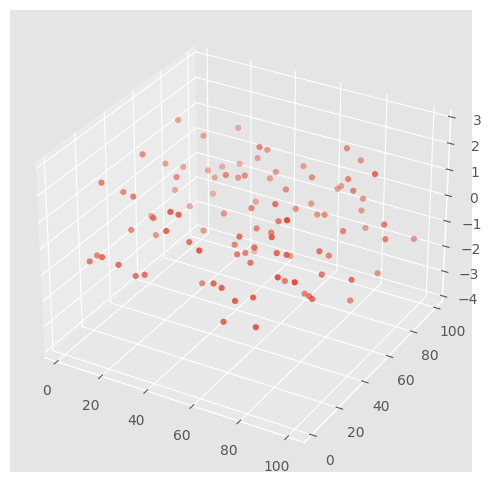

In [10]:
if d == 2:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(grid[:, 0], grid[:,1], f, cmap='viridis', edgecolor='none')
if d == 1:
    plt.scatter(grid, f)

In [11]:
# generate response
pars = {
    "gaussian": {"scale": 0.5},
    "ald": {"q": 0.8, "scale": 0.1},
    "t": {"df": 3, "scale": 1},
    "chi": {"df": 2, "scale": 1}
}

noise = "ald"
print(f.shape)
y = simulate_response(f = f, noise = noise, pars=pars)
print(y.shape)
# get quantile of interest
target_quantile = 0.8
quantiles = obtain_quantile(f, noise, pars, target_quantile)

(100,)
(100,)


In [12]:
y.shape

(100,)

C:\Users\JumpStart\AppData\Local\Temp\ipykernel_4188\4018777181.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(grid[:, 0], grid[:,1], y, cmap='viridis', edgecolor='none')


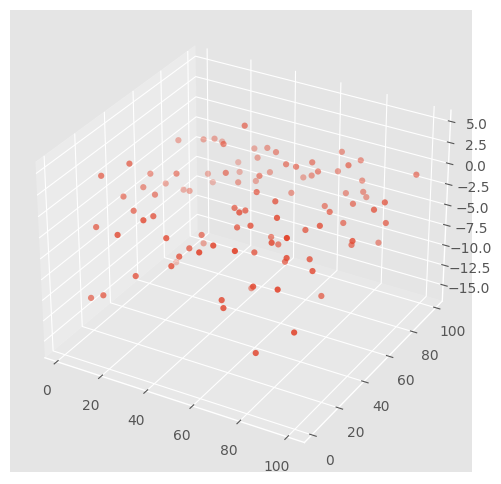

In [13]:
if d == 1:
    plt.scatter(grid, y, color = "black", label = "y")
    plt.scatter(grid, f, label = "f")
    plt.scatter(grid, quantiles, label = f"quantiles {target_quantile}" )
    plt.legend(labelcolor = "black")
    plt.show()
if d == 2:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(grid[:, 0], grid[:,1], y, cmap='viridis', edgecolor='none')

In [14]:
X_train, y_train, X_test, y_test = train_test_split(grid, y, 0.75)

In [15]:
approx = "asymmetric_laplace_constant_curvature_fisher_mode_finding"
pred_gp = model_gpboost(quantile=target_quantile, train_X= X_train, train_y= y_train,
                        test_X= X_test, test_y= y_test, approx=approx,
                         delta_logl = 10)
pred_torch = model_gpytorch(quantile=target_quantile, train_X= X_train,
                            train_y= y_train, test_X=X_test, test_y=y_test, epochs=300, lr = 0.01)

[GPBoost] [Info] Using CC_LLS_MIN_DECREASE_LOG_LIKE_ = 10
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 7, delta_mode_ = 0.0773053, delta_log_like_up_ = 10.0497, delta_log_like_down_ = 10.0496
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 21, delta_mode_ = 3.74908, delta_log_like_up_ = 197.071, delta_log_like_down_ = 381.309
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 19, delta_mode_ = 1.09261, delta_log_like_up_ = 34.7472, delta_log_like_down_ = 47.3919
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 18, delta_mode_ = 0.641621, delta_log_like_up_ = 12.9149, delta_log_like_down_ = 12.0337
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 19, delta_mode_ = 1.4629, delta_log_like_up_ = 22.3944, delta_log_like_down_ = 28.4335
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 19, delta_mode_ = 1.33452, delta_log_like_up_ = 21.3252, delta_log_like_down_ = 26.9339
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 19, del

c:\Users\JumpStart\Documents\environments\latest\Lib\site-packages\torch\distributions\distribution.py:56: UserWarning: <class 'lagp.utils.gpytorch_utils.AsymmetricLaplaceOutput'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


Epoch 0: Loss = 2.6757
Epoch 50: Loss = 2.6072
Epoch 100: Loss = 2.6054
Epoch 150: Loss = 2.6192
Epoch 200: Loss = 2.5999
Epoch 250: Loss = 2.5987


In [16]:
latent_gpb = pred_gp["mu"]
qs_gpb = quantile_score(y = y_test, preds = latent_gpb , quantile = target_quantile)
print(f"GPBoost quantile loss: {qs_gpb}")
latent_gpy = pred_torch.mean.numpy()
qs_gpy = quantile_score(y = y_test, preds = latent_gpy , quantile = target_quantile)
print(f"GPytorch quantile loss: {qs_gpy}")

GPBoost quantile loss: 0.8185326568355025
GPytorch quantile loss: 0.7458698749266156


In [17]:
normv = norm()
alpha = 0.9
t = normv.ppf(1 - (1 - alpha)/2)

In [18]:
gpb_stddev = np.sqrt(pred_gp["var"])
low_gpb = latent_gpb - gpb_stddev * t
up_gpb = latent_gpb +  gpb_stddev * t

gpy_stddev = pred_torch.stddev.numpy()
low_gpy = latent_gpy - gpy_stddev * t
up_gpy = latent_gpy +  gpy_stddev * t

In [19]:
true_quantile = obtain_quantile(f = f, noise = noise, pars = pars, target_quantile=target_quantile)
true_quantile_test = true_quantile[len(y_train): ]
boost_is = interval_score(y=true_quantile_test, pred_low= low_gpb, pred_up= up_gpb, quantile=target_quantile)
print(f"Boost Interval Loss: {boost_is}")

gpy_is = interval_score(y=true_quantile_test, pred_low= low_gpy, pred_up= up_gpy, quantile=target_quantile)
print(f"GPytorch Interval Loss: {gpy_is}")

Boost Interval Loss: 4.820540563142474
GPytorch Interval Loss: 3.474048827655345


C:\Users\JumpStart\Documents\projects\LaGP\src\lagp\utils\metrics.py:45: RuntimeWarning: Mean of empty slice.
  under_prediction = 2 * ((pred_low - y)[(pred_low - y) >= 0]).mean() / quantile
c:\Users\JumpStart\Documents\environments\latest\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0, 0.5, 'True quantile')

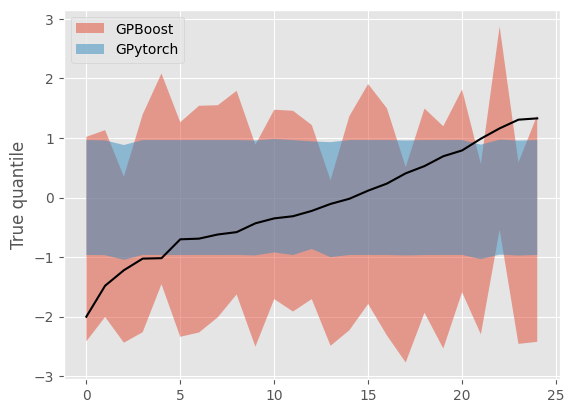

In [20]:
sorted_quantile = np.sort(true_quantile_test)
sort_index = np.argsort(true_quantile_test)

plt.plot(range(len(y_test)),sorted_quantile, color = "black" )
plt.fill_between(range(len(y_test)), y1 = low_gpb[sort_index], y2 = up_gpb[sort_index], alpha = 0.5, label = "GPBoost")

plt.fill_between(range(len(y_test)), y1 = low_gpy[sort_index], y2 = up_gpy[sort_index], alpha = 0.5, label = "GPytorch")
plt.legend(labelcolor = "black")
plt.ylabel("True quantile")

In [21]:
# get models and construct PI for quantile/response

In [22]:
interval_score

<function lagp.utils.metrics.interval_score(y, pred_low, pred_up, quantile)>

In [23]:
coverage_and_width

<function lagp.utils.metrics.coverage_and_width(y: numpy.ndarray, pred_low: numpy.ndarray, pred_up: numpy.ndarray) -> Tuple[float, float]>

In [24]:
# have to adapt my paths since i am inside the notebooks !!
import os
print(os.cpu_count())

18


In [42]:
# load results and analyze them!
import pickle
result_path = "../results/simulation/simulation_results_python.pkl"
with open(result_path, "rb") as f:
    res_python = pickle.load(f)

result_path = "../results/simulation/simulation_results.pkl"
with open(result_path, "rb") as f:
    res = pickle.load(f)

In [36]:
def merge_results(pickle_results_1, pickle_results_2):
    """Merge results from Python (gpboost, gpytorch) and R (qgam, stan)."""
    merged_results = pickle_results_1.copy()

    for config_key, replicate_data in pickle_results_2["results"].items():
        if config_key not in merged_results["results"]:
            merged_results["results"][config_key] = replicate_data
        else:
            # Merge replicate results
            for replicate, model_data in replicate_data.items():
                if replicate not in merged_results["results"][config_key]:
                    merged_results["results"][config_key][replicate] = model_data
                else:
                    for model_name, metrics in model_data.items():
                        if model_name not in merged_results["results"][config_key][replicate]:
                            merged_results["results"][config_key][replicate][model_name] = metrics
                        else:
                            # Handle if same model already exists (merge or overwrite)
                            merged_results["results"][config_key][replicate][model_name].update(metrics)

    return merged_results


In [43]:
merge_results(res, res_python)

{'config': {'simulation': {'seed': 42,
   'grid_lims': [0, 10],
   'sample_sizes': [100, 200],
   'dimensions': [1, 2],
   'likelihoods': ['ald'],
   'pars': {'gaussian': {'scale': 0.5},
    'ald': {'q': 0.8, 'scale': 0.1},
    't': {'df': 3, 'scale': 1},
    'chi': {'df': 2, 'scale': 1}},
   'noise_levels': [0.1, 0.2, 0.3],
   'replicates': 5},
  'gp_parameters': {'kernel': {'type': 'matern',
    'nu': 1.5,
    'lengthscale': 0.5,
    'signal_variance': 2.0}},
  'output': {'data_directory': './data/', 'log_directory': './logs/'},
  'approximation': 'asymmetric_laplace_constant_curvature_fisher_mode_finding',
  'delta_logl': 10,
  'alpha': 0.9,
  'train_split': 0.75,
  'models': ['gpboost', 'gpytorch'],
  'n_epochs': 100,
  'lr': 0.01},
 'results': {'ald_100_1': {5: {'gpboost': {'quantile_loss': np.float64(1.6758101784938273),
     'interval_loss': np.float64(5.91203641888689),
     'coverage': np.float64(0.8),
     'width': np.float64(3.457815904395462)},
    'gpytorch': {'quantile_lo

In [27]:
result_path = "../results/simulation/simulation_results.pkl"
with open(result_path, "rb") as f:
    res = pickle.load(f)
config = res["config"]
results = res["results"]

In [28]:
config

{'simulation': {'seed': 42,
  'grid_lims': [0, 10],
  'sample_sizes': [100, 200],
  'dimensions': [1, 2],
  'likelihoods': ['ald'],
  'pars': {'gaussian': {'scale': 0.5},
   'ald': {'q': 0.8, 'scale': 0.1},
   't': {'df': 3, 'scale': 1},
   'chi': {'df': 2, 'scale': 1}},
  'noise_levels': [0.1, 0.2, 0.3],
  'replicates': 5},
 'gp_parameters': {'kernel': {'type': 'matern',
   'nu': 1.5,
   'lengthscale': 0.5,
   'signal_variance': 2.0}},
 'output': {'data_directory': './data/', 'log_directory': './logs/'},
 'approximation': 'asymmetric_laplace_constant_curvature_fisher_mode_finding',
 'delta_logl': 10,
 'alpha': 0.9,
 'train_split': 0.75,
 'models': ['gpboost', 'gpytorch'],
 'n_epochs': 100,
 'lr': 0.01}

In [29]:
# make it a df
import pandas as pd
df = pd.DataFrame([
    {
        "model": method,
        "likelihood": cfg.split("_")[0],
        "sample_size": int(cfg.split("_")[1]),
        "dim": int(cfg.split("_")[2]),
        "replicate": replicate,
        **metrics,
    }
    for cfg, reps in results.items()
    for replicate, rep_result in reps.items()
    for method, metrics in rep_result.items()
])
df.head()

,model,likelihood,sample_size,dim,replicate,quantile_loss,interval_loss,coverage,width
0,gpboost,ald,100,1,5,1.675810,5.912036,0.80,3.457816
1,gpytorch,ald,100,1,5,1.794742,8.825698,0.48,2.356548
2,gpboost,ald,100,1,1,1.654669,4.922538,1.00,4.922538
3,gpytorch,ald,100,1,1,1.729801,7.107822,0.72,2.732418
4,gpboost,ald,100,1,3,1.083318,8.501536,0.88,3.594127


In [30]:
df.tail()

,model,likelihood,sample_size,dim,replicate,quantile_loss,interval_loss,coverage,width
35,gpytorch,ald,200,2,2,2.041559,8.410977,0.54,2.587843
36,gpboost,ald,200,2,5,1.650080,12.567043,0.84,4.354831
37,gpytorch,ald,200,2,5,1.745472,9.073352,0.64,2.804480
38,gpboost,ald,200,2,3,1.349954,12.738582,0.84,5.412105
39,gpytorch,ald,200,2,3,1.524510,8.637667,0.52,2.508604


In [31]:
metrics_plot = df.columns[5:]

In [32]:
from lagp.utils.analyse_results import make_plots
make_plots(df, metrics_plot)

In [33]:
# Group by likelihood, sample_size, dim, and model_method
grouped = df.groupby(['likelihood', 'sample_size', 'dim', 'model'])

# Assuming 'coverage' and 'width' are columns in your DataFrame
summary_df = grouped.agg(
    quantile_loss_mean=('quantile_loss', 'mean'),
    quantile_loss_std=('quantile_loss', 'std'),
    interval_loss_mean=('interval_loss', 'mean'),
    interval_loss_std=('interval_loss', 'std'),
    coverage_mean=('coverage', 'mean'),
    coverage_std=('coverage', 'std'),
    width_mean=('width', 'mean'),
    width_std=('width', 'std')
).reset_index()

# Display the full summary table
summary_df

,likelihood,sample_size,dim,model,quantile_loss_mean,quantile_loss_std,interval_loss_mean,interval_loss_std,coverage_mean,coverage_std,width_mean,width_std
0,ald,100,1,gpboost,1.487854,0.260422,7.648118,3.459449,0.880,0.074833,4.855505,2.254305
1,ald,100,1,gpytorch,1.526231,0.274597,8.777794,1.053320,0.568,0.107331,2.509891,0.137337
2,ald,100,2,gpboost,1.924363,0.180358,8.720283,2.169789,0.848,0.052154,5.130587,1.698461
3,ald,100,2,gpytorch,2.013960,0.205166,7.680200,0.803941,0.648,0.095499,2.747276,0.152638
4,ald,200,1,gpboost,1.590220,0.202066,6.311485,1.876827,0.848,0.125379,3.225564,0.879674
5,ald,200,1,gpytorch,1.564380,0.239424,6.067522,0.821568,0.480,0.042426,1.888772,0.071091
6,ald,200,2,gpboost,1.736247,0.282901,12.556437,0.855304,0.796,0.077974,5.161079,2.084082
7,ald,200,2,gpytorch,1.750010,0.334165,9.216227,0.877562,0.568,0.050200,2.629805,0.119011


In [34]:
alpha = config["alpha"]
methods = config["models"]
metrics = [
    ("quantile_loss_mean", "quantile_loss_std", "Quantile Score"),  # 3rd element is the name/label
    ("interval_loss_mean", "interval_loss_std", "Interval Score"),
    ("coverage_mean", "coverage_std", "Coverage")
]

# Define metrics and optimality
metric_criteria = {"Quantile Score": "min", "Interval Score": "min", "Coverage": "check_coverage" }

# Optional font size
fontsize = r"\small"  # you can change to \footnotesize, \small, etc.

# Column format
n_methods = len(methods)
n_metrics = len(metrics)
col_format = "lll|" + "c" * (n_metrics * n_methods)
col_format = "|l|l|l" + "|Y" * (n_metrics * n_methods) + "|"

# Multi-column headers for metrics
metric_headers = [fr"\multicolumn{{{n_methods}}}{{c|}}{{\textbf{{{label}}}}}" for _, _, label in metrics]

# Lower headers with the actual method names (one header per method)
method_headers = []
for _ in range(n_metrics):
    method_headers.extend([fr"\textbf{{{method}}}" for method in methods])

# Lower headers for fixed columns (likelihood, sample size, dim)
lower_headers = [r"\textbf{Likelihood}", r"\textbf{N}", r"\textbf{d}"]
lower_headers.extend(method_headers)

# Build the LaTeX header
header = fr"""
\begin{{table}}[ht]
\centering
{fontsize}
\begin{{tabularx}}{{1\textwidth}}{{{col_format}}}
\toprule
\multicolumn{{3}}{{c|}}{{}} & {' & '.join(metric_headers)} \\
{ ' & '.join(lower_headers) } \\
\midrule
"""

# Build table rows
rows = []
for _, group in summary_df.groupby(['likelihood', 'sample_size', 'dim']):
    row = [
        f"{group['likelihood'].iloc[0]}",
        f"{group['sample_size'].iloc[0]}",
        f"{group['dim'].iloc[0]}"
    ]
    
    # For every metric, look for the best value and later make it bold --> use np.isclose
    best_metrics = {}
    for mean_col, std_col, label in metrics:
        if metric_criteria[label] == "min":
            best_value = np.min(group[mean_col])
        elif metric_criteria[label] == "check_coverage":
            closest_idx = np.argmin(np.abs(group[mean_col] - alpha))
            best_value = group[mean_col].iloc[closest_idx]
        else:
            best_value = np.max(group[mean_col])
        best_metrics[label] = best_value

    # For every metric, loop through methods and add results
    for mean_col, std_col, label in metrics:
        for method in methods:
            sub = group[group['model'] == method]
            if not sub.empty:
                mean = sub[mean_col].values[0]
                std = sub[std_col].values[0]
                if np.isclose(mean, best_metrics[label]):
                    row.append(f"\\textbf{{{mean:.3f} ({std:.3f})}}")
                else:
                    row.append(f"{mean:.3f} ({std:.3f})")
            else:
                row.append("–")
    rows.append(" & ".join(row) + r" \\")
                
# Footer
footer = r"""
\bottomrule
\end{tabularx}
\caption{Comparison of models across likelihoods, sample sizes, and dimensions. Each cell shows mean (std).}
\end{table}
"""

# Combine all
latex_table = header + "\n".join(rows) + footer
print(latex_table)

type(latex_table)



\begin{table}[ht]
\centering
\small
\begin{tabularx}{1\textwidth}{|l|l|l|Y|Y|Y|Y|Y|Y|}
\toprule
\multicolumn{3}{c|}{} & \multicolumn{2}{c|}{\textbf{Quantile Score}} & \multicolumn{2}{c|}{\textbf{Interval Score}} & \multicolumn{2}{c|}{\textbf{Coverage}} \\
\textbf{Likelihood} & \textbf{N} & \textbf{d} & \textbf{gpboost} & \textbf{gpytorch} & \textbf{gpboost} & \textbf{gpytorch} & \textbf{gpboost} & \textbf{gpytorch} \\
\midrule
ald & 100 & 1 & \textbf{1.488 (0.260)} & 1.526 (0.275) & \textbf{7.648 (3.459)} & 8.778 (1.053) & \textbf{0.880 (0.075)} & 0.568 (0.107) \\
ald & 100 & 2 & \textbf{1.924 (0.180)} & 2.014 (0.205) & 8.720 (2.170) & \textbf{7.680 (0.804)} & \textbf{0.848 (0.052)} & 0.648 (0.095) \\
ald & 200 & 1 & 1.590 (0.202) & \textbf{1.564 (0.239)} & 6.311 (1.877) & \textbf{6.068 (0.822)} & \textbf{0.848 (0.125)} & 0.480 (0.042) \\
ald & 200 & 2 & \textbf{1.736 (0.283)} & 1.750 (0.334) & 12.556 (0.855) & \textbf{9.216 (0.878)} & \textbf{0.796 (0.078)} & 0.568 (0.050) \\
\bottom

str

In [35]:
# save Overleaf Table in results/simulation
TABLE_DIR = "../results/simulation"
if not os.path.exists(TABLE_DIR):
    os.makedirs(TABLE_DIR)

filename = f"table_results.tex"
filepath = os.path.join(TABLE_DIR, filename)

with open(filepath, "w") as f:
    f.write(latex_table)